In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_classification 
from sklearn.neighbors import KNeighborsClassifier as knn
from sklearn.metrics import accuracy_score, classification_report


# THE MATH BEHIND KNN

## KNN is the simplest ML algorithm. No training phase at all.

## How it works:
### 1. Store all training data
### 2. For a new point, calculate distance to every training point
### 3. Find the K closest neighbors
### 4. Vote: the majority class among K neighbors is the prediction

## Distance metric (Euclidean):
#   d(a, b) = sqrt(sum((a_i - b_i)^2))

### K = number of neighbors to consider
### Small K (e.g., 1): very sensitive to noise, can overfit
### Large K (e.g., 50): very smooth boundaries, can underfit

# No weights, no gradients, no optimization.
# Just: "what are my nearest neighbors doing?"




# KNN CLASSIFIER FROM SCRATCH

In [2]:
class KNNScratch:

    def __init__(self, k=6):
        self.k=k
        self.X_tarin = np.array(X)
        self.y_train = np.array(y)

    def fit(self, X, y):
        self.X_train = X
        self.y_train  = y
        return self

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 -x2) ** 2))

    def _predict_single(self, x):
        distances = np.array([self._euclidean_distance(x, x_train)
                              for  x_train in self.X_train])

        k_nearest_idx = np.argsort(distances)[:self.k]
        k_nearest_labels = self.y_train[k_nearest_idx]


        return np.argmax(np.bincount(k_nearest_labels))

    def predict(self, X):
        return np.array([self._predict_single(x) for x in X])

    def score (self, X, y):
            return np.mean(self.predict(X) == np.array(y))


print("KNNScratch class defined")

KNNScratch class defined


In [4]:
import inspect
print(inspect.signature(KNNScratch.predict))

(self, X)


In [5]:
# GENERATE DATA AND TRAIN 

np.random.seed(42) 

X, y = make_classification(
    n_samples = 300, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1,
    random_state=42
)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = KNNScratch(k=5)
model.fit(X_train, y_train)

print(f"Train accuracy: {model.score(X_train, y_train) * 100:.1f}%")
print(f"Test accuracy: {model.score(X_test, y_test) * 100:.1f}%")

Train accuracy: 95.8%
Test accuracy: 98.3%


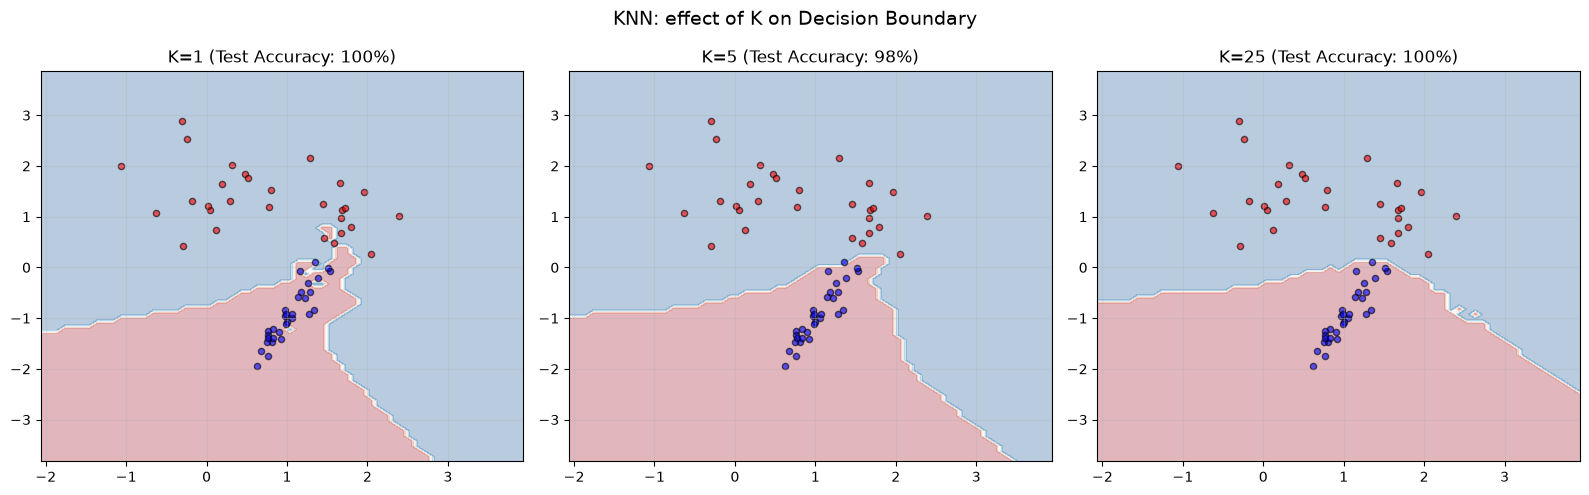

In [9]:
# Effect Of K 
fig, axes = plt.subplots(1, 3,  figsize=(16, 5))

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min,y_max, 0.1))



for ax, k in zip(axes, [1, 5, 25]):
    m = KNNScratch(k=k)
    m.fit(X_train, y_train)

    Z = np.c_[xx.ravel(), yy.ravel()]
    zz = m.predict(Z)
    Z = zz.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1],
               c='blue', alpha=0.6, edgecolors='k', s=20)
    ax.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1],
               c='red', alpha=0.6, edgecolors='k', s=20)

    test_acc = m.score(X_test, y_test) * 100
    ax.set_title(f'K={k} (Test Accuracy: {test_acc:.0f}%)')
    ax.grid(True, alpha=0.3)

plt.suptitle('KNN: effect of K on Decision Boundary', fontsize=14)
plt.tight_layout()
plt.savefig('knn_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
sklearn_m = knn(n_neighbors=7)
sklearn_m.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [12]:
print(f"{'Metric':<20} {'From Scratch':>15} {'Scikit-Learn':>15}")
print(f"{'-'*50}")
print(f"{'Train Accuracy':<20} {m.score(X_train, y_train)*100:>14.1f}% {sklearn_m.score(X_train, y_train)*100:>14.1f}%")
print(f"{'Test Accuracy':<20} {m.score(X_test, y_test)*100:>14.1f}% {sklearn_m.score(X_test, y_test)*100:>14.1f}%")

Metric                  From Scratch    Scikit-Learn
--------------------------------------------------
Train Accuracy                 95.4%           95.4%
Test Accuracy                 100.0%           98.3%


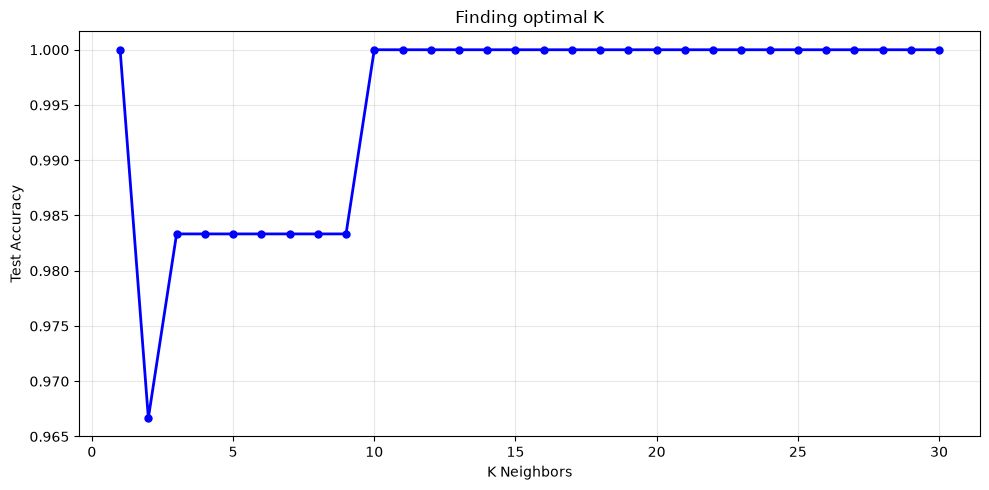

In [16]:
k_values = range (1, 31)
t_scores = []
for k in k_values:
    m = KNNScratch(k=k)
    m.fit(X_train, y_train)
    t_scores.append(m.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(k_values, t_scores, 'bo-', linewidth=2, markersize=5)
plt.xlabel('K Neighbors')
plt.ylabel('Test Accuracy')
plt.title('Finding optimal K')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print("""
============================================================
K-NEAREST NEIGHBORS FROM SCRATCH — COMPLETE
============================================================

What was built:
  - KNNScratch class using only NumPy
  - Euclidean distance calculation
  - K-nearest neighbor search
  - Majority vote classification
  - fit(), predict(), score() methods

Key concepts:
  - KNN has NO training phase, it just stores data
  - Prediction time is slow (calculates distance to every point)
  - Small K = complex boundary (overfitting risk)
  - Large K = smooth boundary (underfitting risk)
  - Feature scaling matters (distances are sensitive to scale)

Verified against scikit-learn: results match.

Next: K-Means Clustering from scratch
============================================================
""")


K-NEAREST NEIGHBORS FROM SCRATCH — COMPLETE

What was built:
  - KNNScratch class using only NumPy
  - Euclidean distance calculation
  - K-nearest neighbor search
  - Majority vote classification
  - fit(), predict(), score() methods

Key concepts:
  - KNN has NO training phase, it just stores data
  - Prediction time is slow (calculates distance to every point)
  - Small K = complex boundary (overfitting risk)
  - Large K = smooth boundary (underfitting risk)
  - Feature scaling matters (distances are sensitive to scale)

Verified against scikit-learn: results match.

Next: K-Means Clustering from scratch

